In [1]:
import json

In [2]:
with open('longplays.json') as f:
    data = json.load(f)

In [3]:
for longplay in data:
    print(longplay['game'])

Pokémon Red
Pokémon Blue
Final Fantasy Legend III
Final Fantasy Legend II
The Final Fantasy Legend
Final Fantasy Adventure
Super Mario Land 2: 6 Golden Coins
Super Mario Land 3: Wario Land
Donkey Kong Land III
Donkey Kong Land 2
Donkey Kong Land
Kirby's Dream Land 2
Super Mario Land
The Legend of Zelda: Link's Awakening
Metroid II: Return of Samus
Donkey Kong
Gargoyle's Quest
Castlevania II: Belmont's Revenge
Mega Man V
Mega Man IV
Mega Man III
Mega Man II
Mega Man: Dr. Wily's Revenge
Battletoads
Contra: The Alien Wars
R-Type
Ninja Gaiden Shadow
Lemmings
Mario's Picross
Tetris Attack
Tetris Plus
Kirby's Block Ball
Tetris
Kid Icarus: Of Myths and Monsters
Kirby's Dream Land


In [3]:
import os
import io
import json
import tempfile

import av
import boto3
import webdataset as wds
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import base64
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
s3 = boto3.client(
    "s3",
    endpoint_url=os.environ["R2_ENDPOINT_URL"],
    aws_access_key_id=os.environ["R2_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["R2_SECRET_ACCESS_KEY"],
)

bucket = "datasets"
prefix = "vision_encoder/DMG/longplays/"

resp = s3.list_objects_v2(Bucket=bucket, Prefix=prefix, MaxKeys=10)
shard_keys = [obj["Key"] for obj in resp["Contents"]]
for k in shard_keys:
    print(k)

vision_encoder/DMG/longplays/000000.tar
vision_encoder/DMG/longplays/000001.tar
vision_encoder/DMG/longplays/000002.tar
vision_encoder/DMG/longplays/000003.tar
vision_encoder/DMG/longplays/000004.tar
vision_encoder/DMG/longplays/000005.tar
vision_encoder/DMG/longplays/000006.tar
vision_encoder/DMG/longplays/000007.tar
vision_encoder/DMG/longplays/000008.tar
vision_encoder/DMG/longplays/000009.tar


In [5]:
# Download the first shard to a temp file and read with WebDataset
shard_key = shard_keys[0]
tmp = tempfile.NamedTemporaryFile(suffix=".tar", delete=False)
s3.download_file(bucket, shard_key, tmp.name)
print(f"Downloaded {shard_key} -> {tmp.name}")

Downloaded vision_encoder/DMG/longplays/000000.tar -> /var/folders/st/4tnj9mbs1_z44dqyd8cyxnt00000gn/T/tmppduzroov.tar


In [6]:
# Read samples from the shard
samples = []
dataset = wds.WebDataset(tmp.name)
for sample in dataset:
    meta = json.loads(sample["json"])
    samples.append({"mp4": sample["mp4"], "meta": meta})
    if len(samples) >= 8:
        break

print(f"Loaded {len(samples)} samples")
for s in samples:
    print(s["meta"])

Loaded 8 samples
{'source_video': 'Pokémon_Red', 'clip_number': 101846, 'start_frame': 1629536, 'end_frame': 1629552}
{'source_video': 'Donkey_Kong_Land_III', 'clip_number': 403, 'start_frame': 6448, 'end_frame': 6464}
{'source_video': 'The_Final_Fantasy_Legend', 'clip_number': 3047, 'start_frame': 48752, 'end_frame': 48768}
{'source_video': "Kirby's_Block_Ball", 'clip_number': 1008, 'start_frame': 16128, 'end_frame': 16144}
{'source_video': 'Mega_Man_II', 'clip_number': 1488, 'start_frame': 23808, 'end_frame': 23824}
{'source_video': "Kirby's_Dream_Land_2", 'clip_number': 9646, 'start_frame': 154336, 'end_frame': 154352}
{'source_video': 'Final_Fantasy_Legend_III', 'clip_number': 43982, 'start_frame': 703712, 'end_frame': 703728}
{'source_video': 'Pokémon_Red', 'clip_number': 10667, 'start_frame': 170672, 'end_frame': 170688}


/Users/jordanlazzaro/projects/agent-1/.venv/lib/python3.12/site-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


In [7]:
def decode_mp4_frames(mp4_bytes: bytes) -> list:
    """Decode an mp4 byte string into a list of numpy frames."""
    with av.open(io.BytesIO(mp4_bytes)) as container:
        return [
            frame.to_ndarray(format="gray")
            for frame in container.decode(video=0)
        ]

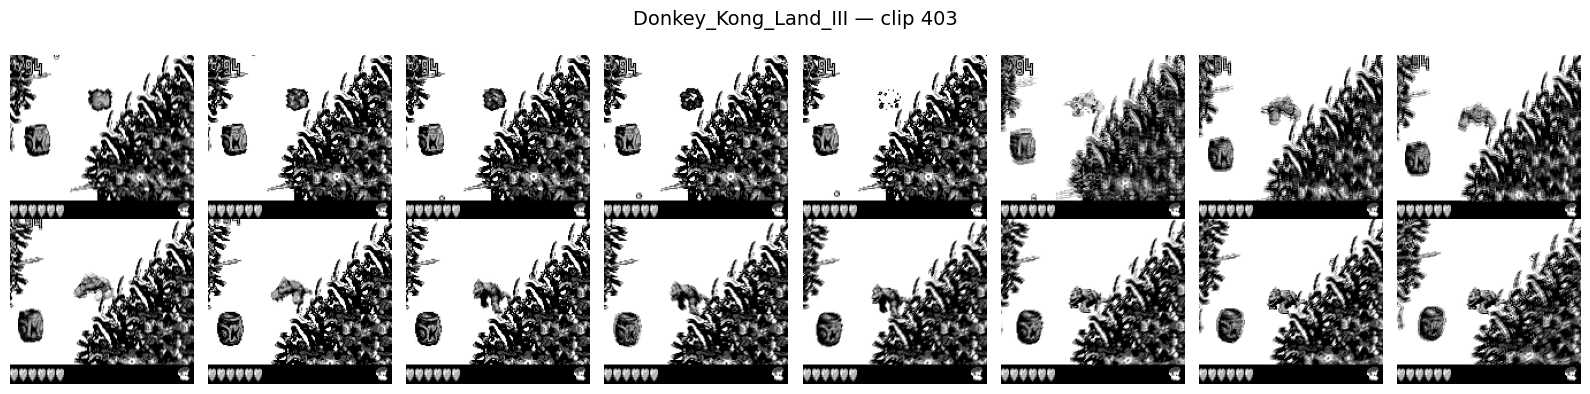

In [8]:
# Show all 16 frames from the first sample as a grid
idx = 1
frames = decode_mp4_frames(samples[idx]["mp4"])
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle(
    f"{samples[idx]['meta']['source_video']} — clip {samples[idx]['meta']['clip_number']}",
    fontsize=14,
)
for i, ax in enumerate(axes.flat):
    if i < len(frames):
        ax.imshow(frames[i], cmap="gray", vmin=0, vmax=255)
    ax.axis("off")
plt.tight_layout()
plt.show()

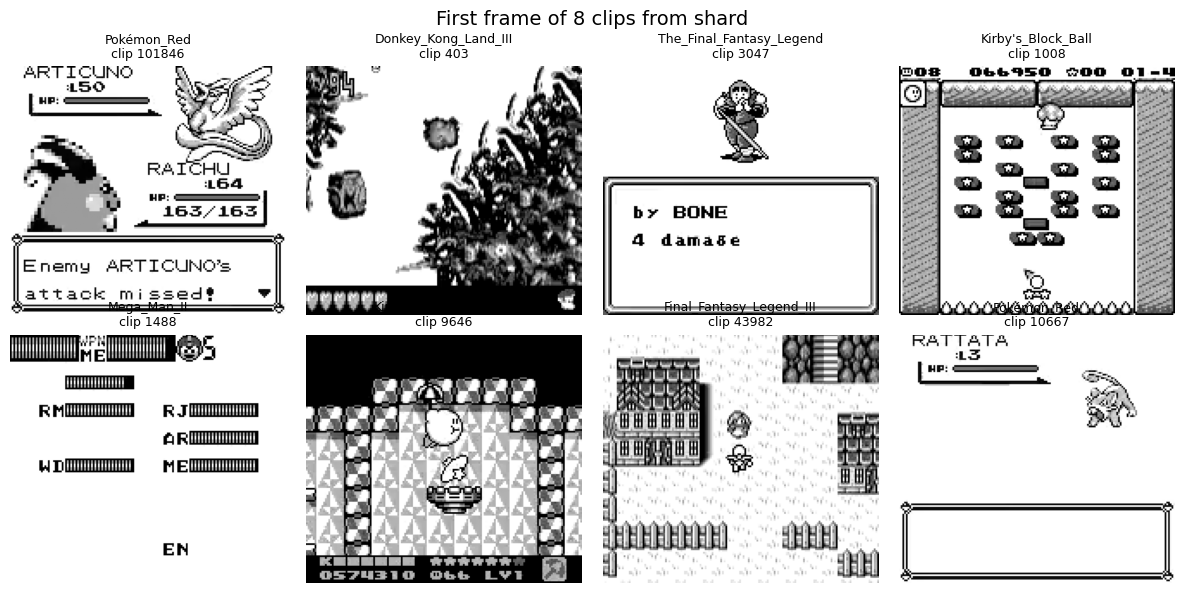

In [9]:
# Show the first frame of each of the 8 sampled clips
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, (ax, s) in enumerate(zip(axes.flat, samples)):
    first_frame = decode_mp4_frames(s["mp4"])[0]
    ax.imshow(first_frame, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{s['meta']['source_video']}\nclip {s['meta']['clip_number']}", fontsize=9)
    ax.axis("off")
plt.suptitle("First frame of 8 clips from shard", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Inline video playback for the first clip
idx = 1
b64 = base64.b64encode(samples[idx]["mp4"]).decode()
meta = samples[idx]["meta"]
display(HTML(
    f"<h4>{meta['source_video']} — clip {meta['clip_number']} "
    f"(frames {meta['start_frame']}–{meta['end_frame']})</h4>"
    f'<video controls loop autoplay muted width="160" height="144" style="image-rendering: pixelated;">'
    f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
    f"</video>"
))

In [2]:
# Inline video playback for a segment of a processed longplay
from pathlib import Path
import av
import io
import base64
from IPython.display import display, HTML

processed_dir = Path.home() / "datasets" / "longplays" / "processed"
video_path = processed_dir / "Donkey_Kong_Land_III.mp4"
start_sec = 60
duration_sec = 10

container = av.open(str(video_path))
stream = container.streams.video[0]
time_base = stream.time_base
start_pts = int(start_sec / time_base)
end_sec = start_sec + duration_sec

container.seek(start_pts, stream=stream)

buf = io.BytesIO()
out = av.open(buf, mode="w", format="mp4")
out_stream = out.add_stream("libx264", rate=stream.average_rate)
out_stream.width = stream.codec_context.width
out_stream.height = stream.codec_context.height
out_stream.pix_fmt = "gray"
out_stream.options = {"movflags": "frag_keyframe+empty_moov"}

for frame in container.decode(video=0):
    if frame.time >= end_sec:
        break
    frame.pts = None
    for packet in out_stream.encode(frame):
        out.mux(packet)

for packet in out_stream.encode():
    out.mux(packet)

out.close()
container.close()

b64 = base64.b64encode(buf.getvalue()).decode()
display(HTML(
    f"<h4>{video_path.stem} ({start_sec}s–{start_sec + duration_sec}s)</h4>"
    f'<video controls loop autoplay muted width="160" height="144" style="image-rendering: pixelated;">'
    f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
    f"</video>"
))

ArgumentError: Invalid argument: '<none>' returned 22

In [12]:
# Cleanup
os.unlink(tmp.name)